In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
meta_df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col = 0)
tree_path = '/home/rsun@ZHANGroup.local/hqy_new/omm_v12_190tax_CDS_tree.nexus'

idx = meta_df['label'] != 2 
species_list = meta_df.index[idx].to_list()
species_list.remove('ZWS')
species_list.remove('shrew_mole')


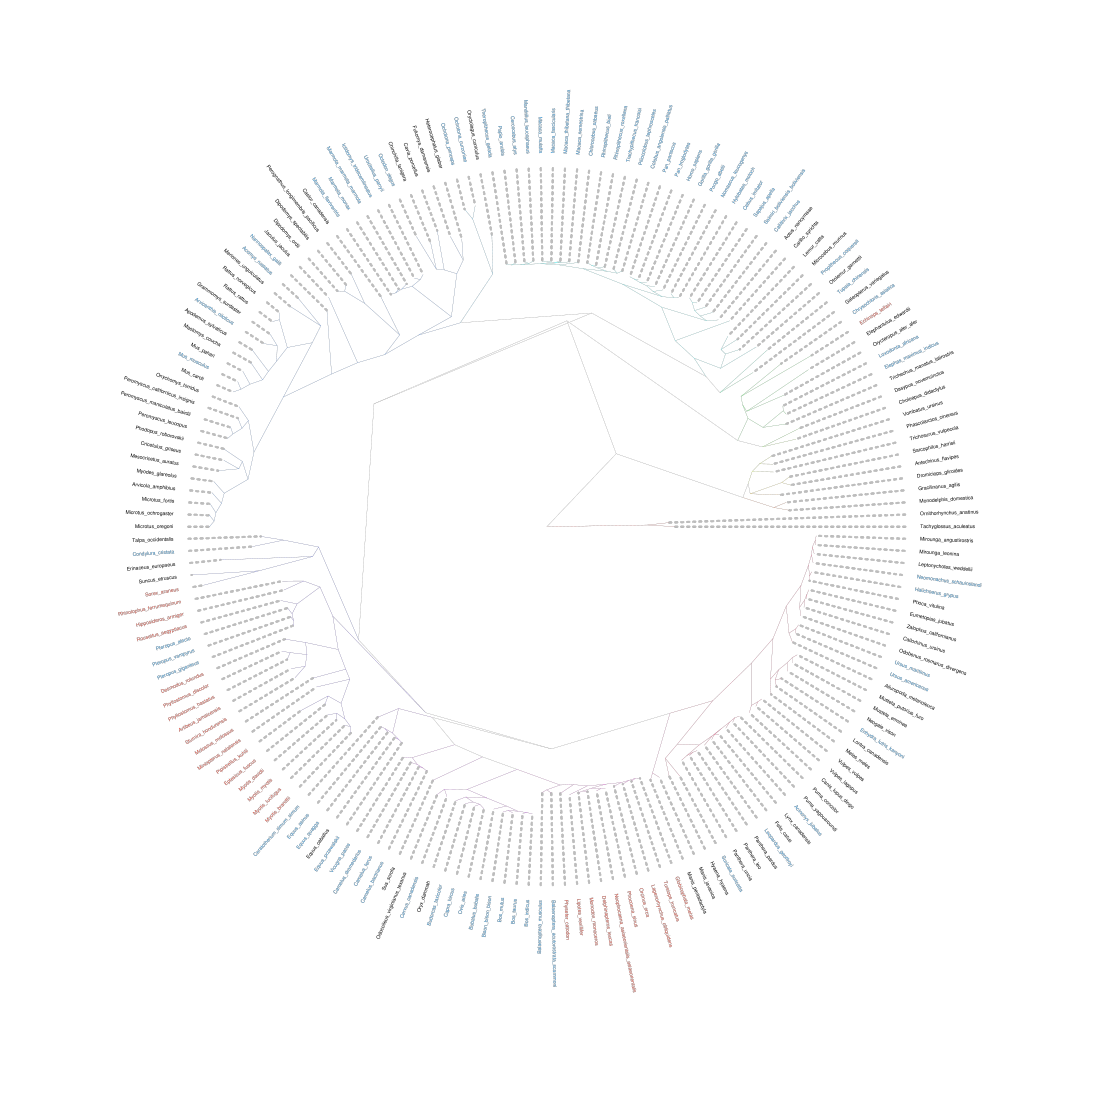

In [4]:
import pandas as pd
import toytree
import toyplot
import numpy as np
import colorsys
from Bio import Phylo
import io

# 1. 数据读取
meta_df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col=0)
tree_path = '/home/rsun@ZHANGroup.local/hqy_new/omm_v12_190tax_CDS_tree.nexus'

# 2. 物种清理
species_list = [s for s in meta_df.index if s not in ['ZWS', 'shrew_mole']]

# 3. 过滤并读取树
tree_bio = Phylo.read(tree_path, 'nexus')
def prune_tree(tree, species_to_keep):
    terminals = tree.get_terminals()
    for terminal in terminals:
        if terminal.name not in species_to_keep:
            tree.prune(terminal)
    return tree

tree_bio_pruned = prune_tree(tree_bio, species_list)
newick_str = io.StringIO()
Phylo.write(tree_bio_pruned, newick_str, 'newick')
tree = toytree.tree(newick_str.getvalue())

# 4. 构建高对比度离散色系 (支持任意数量的“目”)
unique_orders = meta_df.loc[tree.get_tip_labels(), 'order_chinese_new'].unique()
n_colors = len(unique_orders)

def get_distinct_colors(n):
    """手动生成高对比度颜色列表 (HSV空间)"""
    colors = []
    for i in np.arange(0., 360., 360. / n):
        hue = i / 360.
        # 固定饱和度和亮度，确保颜色鲜艳
        rgb = colorsys.hls_to_rgb(hue, 0.5, 0.8)
        colors.append('#%02x%02x%02x' % tuple([int(x*255) for x in rgb]))
    return colors

order_colors = get_distinct_colors(n_colors)
order_color_map = {order: order_colors[i] for i, order in enumerate(unique_orders)}

# 5. 递归计算每个节点的 Order 属性 (toytree v3 逻辑)
# 初始化并给叶节点赋值
for node in tree.get_nodes():
    if node.is_leaf():
        node.order_name = meta_df.loc[node.name, 'order_chinese_new']
    else:
        node.order_name = None

# 后序遍历向上聚合
for node in tree.get_nodes():
    if not node.is_leaf():
        child_orders = set([getattr(c, "order_name", None) for c in node.children])
        if len(child_orders) == 1 and None not in child_orders:
            node.order_name = list(child_orders)[0]

# 6. 生成节点颜色映射并注入树对象
# 重要：edge_colors 渲染的是节点与其父节点之间的连线
# 因此我们将每个节点的颜色特征命名为 "ec" (edge color)
node_idx_to_color = {}
for node in tree.get_nodes():
    name = getattr(node, "order_name", None)
    if name in order_color_map:
        node_idx_to_color[node.idx] = order_color_map[name]
    else:
        node_idx_to_color[node.idx] = "#D3D3D3" # 内部交界处分支用灰色

tree = tree.set_node_data("ec", node_idx_to_color)

# 7. 叶节点文字着色 (红蓝黑)
tip_colors = []
for tip in tree.get_tip_labels():
    label = meta_df.loc[tip, 'label']
    if label == 1.0: tip_colors.append('#e74c3c') # 红
    elif label == 2.0: tip_colors.append("#000000") # 黑
    else: tip_colors.append('#3498db') # 蓝

# 8. 绘图
canvas, axes, mark = tree.draw(
    layout='c',
    edge_type='c',
    width=1100,
    height=1100,
    
    # 需求 1: 英文 ID + 极小字体
    tip_labels=tree.get_tip_labels(),
    tip_labels_colors=tip_colors,
    tip_labels_style={
        "font-size": "5px",
        "font-family": "sans-serif",
    },
    
    # 需求 2: 分支按目着色 (调用注入的 'ec' 特征)
    edge_colors="ec", 
    edge_style={
        "stroke-width": 0.1,
        "stroke-opacity": 1.0
    },
    
    node_labels=False,
    node_sizes=0
)

# 强制刷新文字颜色（针对某些渲染环境）
mark.tip_labels_colors = tip_colors

canvas

In [5]:
# 保存为多种格式
import toyplot.html
import toyplot.svg


# 保存为 SVG - 使用二进制模式
with open("circular_tree.svg", "wb") as f:
    toyplot.svg.render(canvas, f)


## simulated tree for method overview

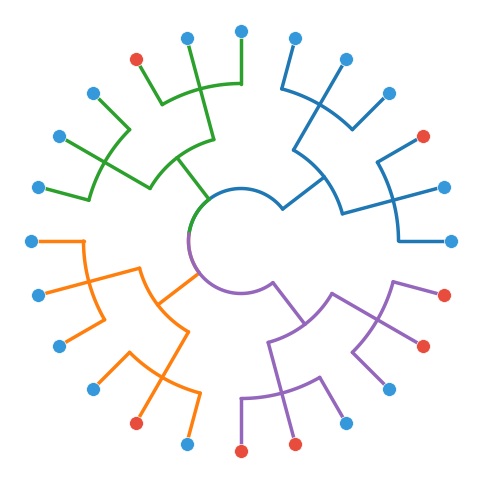

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import io
import random
from Bio import Phylo

# 设置随机种子以保证模拟结果可复现
random.seed(42)

# ==============================
# 1. 模拟数据准备 (4个目，共24个物种)
# ==============================
# 构建一个具有 4 个主分支的 Newick 树，每个主分支代表一个 Order
# 每个 Order 包含 6 个物种
newick_demo = (
    "(( (Sp1,Sp2,Sp3),(Sp4,Sp5,Sp6) ),"  # Order 1
    "( (Sp7,Sp8,Sp9),(Sp10,Sp11,Sp12) )," # Order 2
    "( (Sp13,Sp14,Sp15),(Sp16,Sp17,Sp18) )," # Order 3
    "( (Sp19,Sp20,Sp21),(Sp22,Sp23,Sp24) ));" # Order 4
)

tree = Phylo.read(io.StringIO(newick_demo), 'newick')

# 设置统一的分支长度
for clade in tree.find_clades():
    clade.branch_length = 1.0

# 定义 Order 及其分支颜色 (高对比度)
order_colors = {
    "Order_A": "#1f77b4", # 蓝色
    "Order_B": "#2ca02c", # 绿色
    "Order_C": "#ff7f0e", # 橙色
    "Order_D": "#9467bd"  # 紫色
}

# 映射物种到对应的 Order (每6个一组)
species_to_order = {}
tips = tree.get_terminals()
orders = list(order_colors.keys())
for i, tip in enumerate(tips):
    species_to_order[tip.name] = orders[i // 6]

# --- 关键新增：模拟性状数据 ---
# 为每个物种随机分配一个性状 (0 或 1)
species_traits = {tip.name: random.choice([0, 1]) for tip in tips}

# 定义性状对应的点的颜色
# 0 -> 蓝色 (代表无), 1 -> 红色 (代表有)
trait_dot_colors = {
    0: "#3498db", # 蓝色 (代表无)
    1: "#e74c3c"  # 红色 (代表有)
}

# ==============================
# 2. 递归分支着色逻辑
# ==============================
def get_clade_color(clade):
    """如果该分支下所有叶节点属于同一 Order，则返回该分支的颜色"""
    if clade.is_terminal():
        # 这里返回 Order 对应的分支颜色，而不是点的颜色
        return order_colors[species_to_order[clade.name]]
    
    # 获取子节点对应的分支颜色
    child_colors = set([get_clade_color(c) for c in clade.clades])
    # 如果所有子分支属于同一个目，则该内部祖先分支也染上这个目的颜色
    if len(child_colors) == 1:
        return list(child_colors)[0]
    # 根部或多个目汇合处使用中性灰色
    return "#D3D3D3" 

# ==============================
# 3. 环状布局绘制函数
# ==============================
def plot_icon_tree(tree, ax):
    depths = tree.depths(unit_branch_lengths=True)
    terminals = tree.get_terminals()
    n_tips = len(terminals)
    
    # 计算角度
    tip_angles = {tip.name: 2 * np.pi * i / n_tips for i, tip in enumerate(terminals)}

    def get_node_angle(node):
        if node.is_terminal(): return tip_angles[node.name]
        return np.mean([get_node_angle(c) for c in node.clades])

    def polar_to_cart(r, theta):
        return r * np.cos(theta), r * np.sin(theta)

    def draw_node(node, parent_r=None, parent_theta=None):
        node_r = depths.get(node, 0)
        node_theta = get_node_angle(node)
        nx, ny = polar_to_cart(node_r, node_theta)
        
        branch_color = get_clade_color(node)
        
        if parent_r is not None:
            px, py = polar_to_cart(parent_r, parent_theta)
            # 绘制弧线
            thetas = np.linspace(min(parent_theta, node_theta), max(parent_theta, node_theta), 50)
            ax.plot(parent_r * np.cos(thetas), parent_r * np.sin(thetas), color=branch_color, lw=2.5, solid_capstyle='round', zorder=1)
            # 绘制径向线
            ax.plot([parent_r * np.cos(node_theta), nx], [parent_r * np.sin(node_theta), ny], color=branch_color, lw=2.5, solid_capstyle='round', zorder=1)
        
        # --- 关键修正：绘制叶节点圆点 (使用代表性状的红色/蓝色) ---
        if node.is_terminal():
            # 获取该物种的性状标签 (0 或 1)
            trait_label = species_traits[node.name]
            # 根据标签获取点的颜色
            dot_color = trait_dot_colors[trait_label]
            # 绘制圆点 (不加名称)
            ax.scatter(nx, ny, s=100, color=dot_color, zorder=3, edgecolors='white', lw=0.5)

        for child in node.clades:
            draw_node(child, parent_r=node_r, parent_theta=node_theta)

    draw_node(tree.root)

# ==============================
# 4. 生成可视化
# ==============================
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.axis('off')

plot_icon_tree(tree, ax)

# # --- 关键新增：添加图例 ---
# legend_elements = [
#     mpatches.Patch(facecolor=trait_dot_colors[1], edgecolor='none', label='Trait Present (label=1)'),
#     mpatches.Patch(facecolor=trait_dot_colors[0], edgecolor='none', label='Trait Absent (label=0)')
# ]
# ax.legend(handles=legend_elements, loc='lower right', fontsize=8, frameon=False, bbox_to_anchor=(1.05, -0.05))

# 保存为 SVG 矢量图作为论文素材
# output_path = '/path/to/save/tree_method_icon_with_trait.svg'
fig.savefig('tree_icon.svg', format='svg', bbox_inches='tight', transparent=True)
# print(f"Icon 已保存至: {output_path}")

plt.show()